# Grain boundary segmentation - Pixelated: Part - 1
### **Topics**
- `Process segments`
- `Overviews`

## Introduction

This notebook demonstrates **grain boundary segmentation** using UPXO's Monte-Carlo grain structure (MCGS) framework. The workflow extracts and characterizes individual grain boundary segments from a 2D polycrystalline microstructure simulation.

### Key Capabilities

1. **Grain Boundary Detection**: Identify boundaries between neighboring grains in a pixelated microstructure
2. **Boundary Segmentation**: Decompose grain boundaries into discrete segments connecting junction points
3. **Topological Analysis**: Characterize junction points (triple/quadruple junctions) and segment connectivity
4. **Quantitative Characterization**: Compute segment properties (length, orientation, neighboring grain IDs)

### Applications

- **Microstructure Analysis**: Study grain boundary network topology and morphology
- **Finite Element Meshing**: Prepare boundary-conforming meshes for FEA simulations
- **Material Property Prediction**: Correlate boundary characteristics with mechanical/thermal properties
- **Grain Boundary Engineering**: Design microstructures with specific boundary distributions
- **Phase Field Validation**: Compare simulated grain structures against experimental data

### Workflow Overview

This notebook follows a typical UPXO analysis pipeline:

1. Load configuration from Excel dashboard (`gschar3.xls`)
2. Run Monte-Carlo grain growth simulation
3. Detect grains using connected component labeling
4. Identify grain neighbors and compute morphological properties
5. **Extract grain boundaries** as pixelated segments
6. **Segment boundaries** at junction points into individual boundary entities
7. **Characterize segments** (coordinates, connectivity, statistics)
8. Visualize results with labeled boundary segments

### Advantages for Users

- **Automated Workflow**: Pipelines (`PL_*` functions) combine multiple operations for rapid analysis
- **Flexible Output**: Export segmented boundaries to VTK, ABAQUS, or MATLAB formats
- **Scalable**: Handles 2D/3D microstructures with thousands of grains
- **Integration-Ready**: Boundary segment data feeds directly into meshing (`upxo.meshing`) or FEA preprocessing
- **Validation Tools**: Compare segment statistics against experimental EBSD/microscopy data

Use this approach to bridge microstructure simulation and downstream computational mechanics workflows.

In [62]:
from upxo.ggrowth.mcgs import mcgs
import numpy as np
import matplotlib.pyplot as plt
import time
from collections import defaultdict
import upxo.gsdataops.grid_ops as gridOps
from skimage.segmentation import find_boundaries
import upxo.gbops.mcgb2dops as gbops2d

## Configuration Setup

This cell defines the input configuration file path for the UPXO Monte-Carlo grain structure simulation:

```python
input_dashboard = 'C:\\Development\\UPXO\\upxo_library\\src\\upxo\\demos\\gschar\\gschar3.xls'
```

**Purpose**: Specifies the Excel dashboard containing simulation parameters (grid dimensions, Monte-Carlo settings, interaction weights).

**Key Parameters** (loaded from `gschar3.xls`):
- **Grid**: Domain boundaries (x: 0-25, y: 0-25) with unit spacing
- **Simulation**: 5 orientation states, 20 Monte-Carlo steps, algorithm 200.0
- **Output**: Configuration for grain detection and boundary characterization

This path is passed to the `mcgs` constructor in the next cell to initialize the grain growth simulation.

In [63]:
input_dashboard = 'C:\\Development\\UPXO\\upxo_library\\src\\upxo\\demos\\gschar\\gschar3.xls'

## Simulation and Grain Characterization

This section performs the core Monte-Carlo grain growth simulation and characterizes the resulting microstructure.

### Operations Performed

1. **Initialize MCGS Object**
    - Loaded configuration from `gschar3.xls` Excel dashboard
    - Set up 2D grid (25×25 domain with unit spacing)
    - Configured 5 orientation states with algorithm 200.0

2. **Run Monte-Carlo Simulation**
    - `pxt.simulate()`: Executed 20 Monte-Carlo steps to evolve grain structure
    - Algorithm 200.0 updates orientation states based on local interaction energy

3. **Detect Grains**
    - `pxt.detect_grains(library='cc3d', process_individual_states=True)`: 
      - Used connected-components-3d library for fast grain labeling
      - Processed each orientation state independently to identify distinct grains
      - Stored labeled grain image (LGI) at temporal slice 3

4. **Morphological Characterization**
    - `pxt.gs[3].char_morph_2d(npixels=True)`: 
      - Computed grain areas (number of pixels per grain)
      - Stored properties in `pxt.gs[3].g[gid].prop` dictionaries

5. **Neighbor Detection**
    - `pxt.gs[3].find_neigh(include_central_grain=True, ...)`:
      - Identified adjacent grain pairs by analyzing boundary pixels
      - Built neighbor connectivity graph stored in `pxt.gs[3].neigh_gid`
      - Updated grain objects with neighbor lists
      - Used pure Python implementation (`use_numba=False`) for compatibility

### Output Data Structures

- **`pxt.gs[3].lgi`**: Labeled grain image (26×26 array with grain IDs)
- **`pxt.gs[3].n`**: Total number of grains detected
- **`pxt.gs[3].neigh_gid`**: Dictionary mapping grain IDs to lists of neighboring grain IDs
- **`pxt.gs[3].g[gid].prop`**: Per-grain property dictionaries (area, etc.)

This data feeds into the grain boundary segmentation pipeline in subsequent cells.

In [64]:
pxt = mcgs(input_dashboard=input_dashboard)
pxt.simulate()
pxt.detect_grains(library='cc3d', process_individual_states=True)
# pxt.gs[3].lgi = np.asarray(pxt.gs[3].lgi, dtype=np.int32)
pxt.gs[3].char_morph_2d(npixels=True)
pxt.gs[3].find_neigh(include_central_grain=False, print_msg=True, use_numba=False,
                     user_defined_bbox_ex_bounds=False, bbox_ex_bounds=None,
                     update_grain_object=True)


C:\Development\UPXO\upxo_library\src\upxo\interfaces\user_inputs
C:\Development\UPXO\upxo_library\src\upxo\demos\gschar\gschar3.xls
Algo_hops details
(('200.0', 100),)
[False]

 Initiating Monte-Carlo simulation
     xmin, xmax, xinc: 0.0, 25.0, 1.0
     ymin, ymax, yinc: 0.0, 25.0, 1.0
     zmin, zmax, zinc: 0.0, 100.0, 1.0
     No. of states: 5
     Dimensionality: 2
Using ALG-200: SA's SL NL-1 TP1 C2 unweighted Q-Pott's model:
|--------------- MC SIM RUN IN PROGRESS on: ALG200---------------|
GS temporal slice 0 stored
GS temporal slice 1 stored
GS temporal slice 2 stored
GS temporal slice 3 stored
GS temporal slice 4 stored
GS temporal slice 5 stored
GS temporal slice 6 stored
GS temporal slice 7 stored
GS temporal slice 8 stored
GS temporal slice 9 stored
GS temporal slice 10 stored
GS temporal slice 11 stored
GS temporal slice 12 stored
GS temporal slice 13 stored
GS temporal slice 14 stored
GS temporal slice 15 stored
GS temporal slice 16 stored
GS temporal slice 17 stored
GS te

### See the Labelled feature image

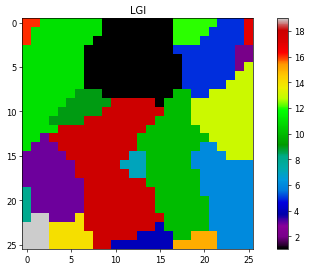

In [65]:
plt.figure(figsize=(10, 5), dpi=60)
plt.imshow(pxt.gs[3].lgi, cmap='nipy_spectral')
plt.title('LGI')
plt.colorbar()

# Grain boundary detection
Here, `detect_cell_boundaries` orchastrates the scikit-image image segmentation function `find_boundary` and ports user input arguments accordingly. We will need to provide `lfi`, `nfeatures` (ex: number of grains / cells in the lfi array), `connectivity`, `mode` and `background`. 

We will not elaborate all details of the latter 3 in this notebook file, instead provide basic information only. 

- `connectivity`: pixel to pixel connectivity for use in cell boundary feature identification. A value of 1 gives a unsmooth stepped boundary morphology while 2 gives a smoother but still stepped boundary morphology.
- `mode`: valid options for the current cell boundary identification technique are *thick*, *inner* and *outer*. You can find their details in the below link.
- `background`: Specify what counts as background. For example, if we designate all grains to be 0 and all precipitates to be their respective feature ID numbers in their corresponding *lfi* arrays, then we woudl only process the precipitates ignoring the background grains.

We advice the user to refer to this link for more information. 
[skimage.segmentation.find_boundaries](https://scikit-image.org/docs/stable/api/skimage.segmentation.html#skimage.segmentation.find_boundaries).

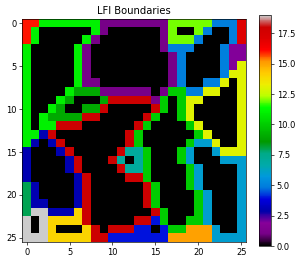

In [66]:
lfi_boundaries = gbops2d.detect_cell_boundaries(lfi=pxt.gs[3].lgi, 
                                nfeatures=pxt.gs[3].n, connectivity=1,
                                mode='thick', background=0)
plt.figure(figsize=(6, 5), dpi=60)
plt.imshow(lfi_boundaries, cmap='nipy_spectral')
plt.title('LFI Boundaries')
plt.colorbar()

# Grain boundary segmentation

In [67]:
segInfo = gbops2d.segment_cell_boundaries(lfi=pxt.gs[3].lgi, 
                                    lfi_boundaries=lfi_boundaries,
                                    neigh_fid=pxt.gs[3].neigh_gid,
                                    connectivity=1,
                                    local_seg_id_nDecPlaces=4)

Segmentation successfull Number of bsegCoords equals number of nearest neighs for all features.


In [68]:
segInfo.keys()

dict_keys(['bsegCoords', 'local_seg_ids', 'global_seg_ids', 'segidList_lcl', 'segidList_gbl', 'segid_gbl_pfid_map'])

# Grain boundary segment characterisation

In [69]:
bseg_props = gbops2d.characterise_boundary_segments(segInfo['bsegCoords'], pxt.gs[3].neigh_gid)

# Make masks of segment IDs

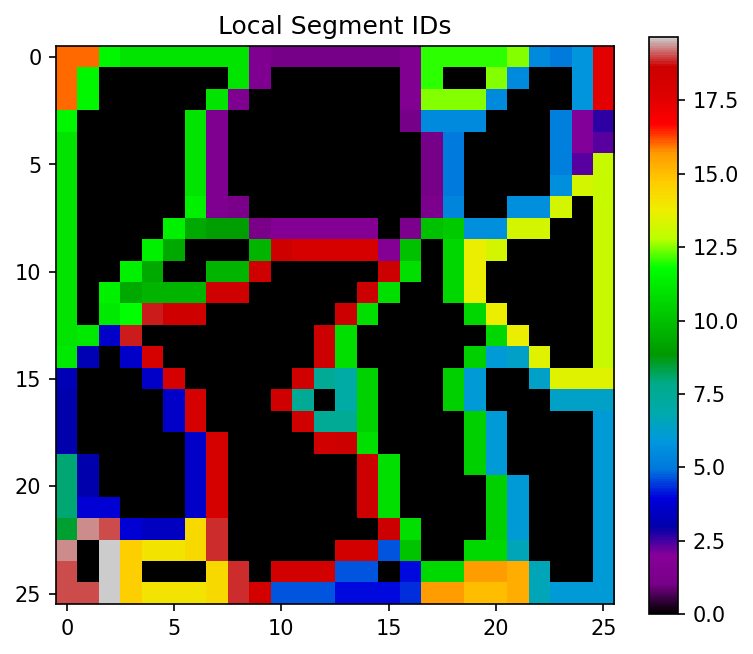

In [70]:
localSegIDMasked_lfi = gridOps.mask_featIDImg_at_coords(lfi_boundaries, segInfo['bsegCoords'], segInfo['local_seg_ids'],
                            featName='fbseg', maskDType=np.int32)
plt.figure(figsize=(6, 5), dpi=150)
plt.imshow(localSegIDMasked_lfi, cmap='nipy_spectral')
plt.title('Local Segment IDs')
plt.colorbar()

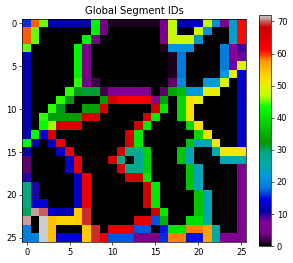

In [71]:
globalSegIDMasked_lfi = gridOps.mask_featIDImg_at_coords(lfi_boundaries, segInfo['bsegCoords'], segInfo['global_seg_ids'],
                            featName='fbseg', maskDType=np.int32)
plt.figure(figsize=(6, 5), dpi=60)
plt.imshow(globalSegIDMasked_lfi, cmap='nipy_spectral')
plt.title('Global Segment IDs')
plt.colorbar()

# Working with grain boundary junction points

In [72]:
junctionPoints =  gbops2d.detect_junction_points(segInfo['bsegCoords'])
JPOStats = gbops2d.find_basic_JPO_stats(junctionPoints, segInfo['segidList_gbl'])
JPSorted = gbops2d.sort_junction_points(junctionPoints)

# Data structures

All data structures are explained in the notebook **`gschar7.ipynb`**